# Generating Psalm- and Proverb-Style Text in Spanish with a Character-Level GPT Trained from Scratch

**Name:** Arturo Ramos
**Dataset:** *Santa Biblia — Reina Valera 1909* (public domain), plain-text verse-per-line edition from eBible.org — https://ebible.org/find/details.php?id=spaRV1909 — file `data/spaRV1909_vpl.txt`

**Generative task.** This is **Transformer-based text generation**. A small decoder-only Transformer (a GPT-style language model) is trained from scratch, character by character, to generate new Spanish text in the style of the poetic and wisdom books of the 1909 Reina-Valera Bible, the Psalms (*Salmos*) and Proverbs (*Proverbios*). Training has two phases: pre-training on the whole Bible teaches the model 1909 Spanish, and fine-tuning on Psalms and Proverbs teaches it their style. Each verse is prefixed with its book code (`PSA:` or `PRO:`), so the prefix works as a prompt that asks for one style or the other. The system produces short verse-like lines; it is a study of how a generative model imitates a sacred text, not a tool for producing scripture.

## 1. Setup

In [1]:
import os
os.environ.setdefault("CUBLAS_WORKSPACE_CONFIG", ":4096:8")   # required for deterministic cuBLAS kernels

import math
import random
import re
import time
import unicodedata
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.width", 160)
pd.set_option("display.max_colwidth", 140)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.use_deterministic_algorithms(True, warn_only=True)
torch.backends.cudnn.benchmark = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DATA_FILE = Path("data") / "spaRV1909_vpl.txt"
FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)
print("torch", torch.__version__, "| device:", DEVICE, "|", torch.cuda.get_device_name(0) if DEVICE.type == "cuda" else "CPU")

torch 2.11.0+cu128 | device: cuda | NVIDIA GeForce RTX 3060 Ti


## 2. Load and Inspect the Data

The eBible.org "VPL" edition has one verse per line in the form `BOOK chapter:verse text`, with all headings, notes and paragraph marks removed.

In [2]:
lines = DATA_FILE.read_text(encoding="utf-8-sig").splitlines()
pattern = re.compile(r"^(\w{3}) (\d+):(\d+) (.*)$")
parsed = [pattern.match(l) for l in lines]
print("lines:", len(lines), "| lines that do not match 'BOOK c:v text':", sum(p is None for p in parsed))

verses = pd.DataFrame([p.groups() for p in parsed], columns=["book", "chapter", "verse", "text"])
verses["chapter"] = verses["chapter"].astype(int)
verses["verse"] = verses["verse"].astype(int)
verses["chars"] = verses["text"].str.len()
print("books:", verses["book"].nunique(), "| total characters:", f"{verses['chars'].sum():,}")
verses.head()

lines: 31102 | lines that do not match 'BOOK c:v text': 0
books: 66 | total characters: 3,787,652


,book,chapter,verse,text,chars
0,GEN,1,1,EN el principio crió Dios los cielos y la tierra.,49
1,GEN,1,2,"Y la tierra estaba desordenada y vacía, y las tinieblas estaban sobre la haz del abismo, y el Espíritu de Dios se movía sobre la haz de ...",146
2,GEN,1,3,Y dijo Dios: Sea la luz: y fué la luz.,38
3,GEN,1,4,Y vió Dios que la luz era buena: y apartó Dios la luz de las tinieblas.,71
4,GEN,1,5,"Y llamó Dios á la luz Día, y á las tinieblas llamó Noche: y fué la tarde y la mañana un día.",92


In [3]:
# Representative samples: the two target books and a narrative book for contrast
pd.concat([verses[(verses.book == "PSA") & (verses.chapter == 23)].head(3),
           verses[(verses.book == "PRO") & (verses.chapter == 3)].iloc[4:7],
           verses[(verses.book == "GEN") & (verses.chapter == 1)].head(2)])[["book", "chapter", "verse", "text"]]

,book,chapter,verse,text
14236,PSA,23,1,Salmo de David. JEHOVÁ es mi pastor; nada me faltará.
14237,PSA,23,2,En lugares de delicados pastos me hará yacer: junto á aguas de reposo me pastoreará.
14238,PSA,23,3,Confortará mi alma; guiaráme por sendas de justicia por amor de su nombre.
16460,PRO,3,5,"Fíate de Jehová de todo tu corazón, y no estribes en tu prudencia."
16461,PRO,3,6,"Reconócelo en todos tus caminos, y él enderezará tus veredas."
16462,PRO,3,7,"No seas sabio en tu opinión: teme á Jehová, y apártate del mal;"
0,GEN,1,1,EN el principio crió Dios los cielos y la tierra.
1,GEN,1,2,"Y la tierra estaba desordenada y vacía, y las tinieblas estaban sobre la haz del abismo, y el Espíritu de Dios se movía sobre la haz de ..."


In [4]:
target = verses[verses["book"].isin(["PSA", "PRO"])]
summary = pd.DataFrame({
    "verses": [len(verses), len(target), (verses.book == "PSA").sum(), (verses.book == "PRO").sum()],
    "characters": [verses.chars.sum(), target.chars.sum(), verses.loc[verses.book == "PSA", "chars"].sum(), verses.loc[verses.book == "PRO", "chars"].sum()],
    "median characters per verse": [verses.chars.median(), target.chars.median(), verses.loc[verses.book == "PSA", "chars"].median(), verses.loc[verses.book == "PRO", "chars"].median()],
}, index=["whole Bible", "Psalms + Proverbs", "Psalms", "Proverbs"])
summary

,verses,characters,median characters per verse
whole Bible,31102,3787652,114.0
Psalms + Proverbs,3376,283124,79.0
Psalms,2461,208764,78.0
Proverbs,915,74360,80.0


In [5]:
# Character inventory and orthographic features of the 1909 text
all_text = "".join(verses["text"])
char_counts = Counter(all_text)
print("distinct characters:", len(char_counts))
print("".join(sorted(char_counts)))
features = {
    "verses with square brackets [ ]": int(verses["text"].str.contains(r"\[").sum()),
    "occurrences of the preposition 'á'": len(re.findall(r"\bá\b", all_text)),
    "occurrences of 'fué'": len(re.findall(r"\bfué\b", all_text)),
    "Psalm verses that start with a heading ('Salmo de ...')": int(verses[(verses.book == "PSA")]["text"].str.match(r"^(Salmo|Al Músico|Masquil|Mictam|Oración)").sum()),
    "verses whose first word is fully upper-case": int(verses["text"].str.match(r"^[A-ZÁÉÍÓÚÑ]{2,}\b").sum()),
}
pd.Series(features, name="count")

distinct characters: 83
 !(),-.:;?ABCDEFGHIJKLMNOPQRSTUVXYZ[]abcdefghijklmnopqrstuvxyz¡¿ÁÉÍÎÑÓÚáâéêíîñóôúûü


verses with square brackets [ ]                             3080
occurrences of the preposition 'á'                         19320
occurrences of 'fué'                                        1650
Psalm verses that start with a heading ('Salmo de ...')       93
verses whose first word is fully upper-case                  593
Name: count, dtype: int64

**Structure, formats and preprocessing considerations**

- The file has 31,102 verse lines from the 66 books, about 3.8 million characters in total and only 83 distinct characters, which makes a character-level model small and practical: the vocabulary fits in less than a hundred symbols and no word can be out of vocabulary.
- The two target books are a small part of the corpus: Psalms and Proverbs together have 3,376 verses (about 7 % of the characters). A model trained only on them would see too little Spanish to learn spelling and grammar, which motivates pre-training on the whole Bible first.
- The text keeps the 1909 orthography (for example the preposition *á* written with an accent and *fué* with an accent), which is part of the style to be imitated, so it is **not** modernized.
- Square brackets mark words added by the translators for clarity. They are editorial marks rather than language, so the brackets are removed and the words kept.
- Some verses start with a fully upper-case word (the first word of a chapter, as in *EN el principio*), and the first verse of many Psalms contains its heading (*Salmo de David.*). Both are kept: they are part of how the text looks, and the model will reproduce them.

## 3. Preprocessing and Data Splits

In [6]:
def clean_verse(text: str) -> str:
    """Normalize one verse: Unicode NFC, remove the translators' square brackets, collapse whitespace."""
    text = unicodedata.normalize("NFC", text).replace("[", "").replace("]", "")
    return re.sub(r"\s+", " ", text).strip()


def to_training_line(book: str, text: str) -> str:
    """Format a verse as one training line: the book code works as a style prompt, the newline ends the verse."""
    return f"{book}: {text}\n"


verses["clean"] = verses["text"].map(clean_verse)

# Split by CHAPTER so that validation verses never share a chapter with training verses
chapters = sorted(set(zip(verses.book, verses.chapter)))
random.Random(SEED).shuffle(chapters)
val_chapters = set(chapters[: int(0.10 * len(chapters))])
verses["split"] = ["val" if (b, c) in val_chapters else "train" for b, c in zip(verses.book, verses.chapter)]

def corpus(frame: pd.DataFrame) -> str:
    return "".join(to_training_line(b, t) for b, t in zip(frame["book"], frame["clean"]))

is_target = verses["book"].isin(["PSA", "PRO"])
texts = {
    "pretrain_train": corpus(verses[verses.split == "train"]),
    "pretrain_val": corpus(verses[verses.split == "val"]),
    "finetune_train": corpus(verses[(verses.split == "train") & is_target]),
    "finetune_val": corpus(verses[(verses.split == "val") & is_target]),
}
pd.DataFrame({"characters": {k: len(v) for k, v in texts.items()},
              "lines (verses)": {k: v.count("\n") for k, v in texts.items()}})

,characters,lines (verses)
pretrain_train,3570789,27970
pretrain_val,396473,3132
finetune_train,268972,3002
finetune_val,33412,374


In [7]:
# Character vocabulary (from the training text) and encoding
VOCAB = sorted(set(texts["pretrain_train"]))
STOI = {c: i for i, c in enumerate(VOCAB)}
ITOS = {i: c for c, i in STOI.items()}
missing = set(texts["pretrain_val"]) - set(VOCAB)
print("vocabulary size:", len(VOCAB), "| characters in validation but not in training:", missing or "none")

def encode(s: str) -> torch.Tensor:
    return torch.tensor([STOI[c] for c in s], dtype=torch.long)

def decode(ids) -> str:
    return "".join(ITOS[int(i)] for i in ids)

data = {k: encode(v) for k, v in texts.items()}
print({k: tuple(v.shape) for k, v in data.items()})
print("example line:", repr(texts["finetune_train"][:120]))

vocabulary size: 85 | characters in validation but not in training: none


{'pretrain_train': (3570789,), 'pretrain_val': (396473,), 'finetune_train': (268972,), 'finetune_val': (33412,)}
example line: 'PSA: BIENAVENTURADO el varón que no anduvo en consejo de malos, ni estuvo en camino de pecadores, ni en silla de escarne'


**What was done and why**

- **Cleaning** is deliberately minimal: Unicode normalization, removal of the translators' brackets and whitespace collapsing. The archaic spelling is the target style and is left untouched.
- **Training format.** Each verse becomes one line, `PSA: …` or `PRO: …` (or the code of any other book during pre-training). The book code is a lightweight *conditioning prompt*: at generation time, starting from `PRO: ` asks the model for a proverb-style line. The newline marks the end of a generated verse.
- **Chapter-level split (90 / 10 %).** Verses of the same chapter share wording and repetitions (the refrain of Psalm 136 appears in every verse), so validation chapters are held out entirely. The fine-tuning splits are the Psalms and Proverbs chapters of the same two splits, so no validation chapter is ever used for training in either phase.
- **Character vocabulary** of the training text; every validation character is covered.

## 4. Model: a Character-Level GPT

The model is a decoder-only Transformer, the architecture of the GPT family, written from scratch:

- **Token and position embeddings** (dimension 384, context of 192 characters).
- **6 Transformer blocks**, each with pre-layer-normalization, **causal multi-head self-attention** (6 heads) and a feed-forward network (4 × 384 with GELU), both with residual connections and dropout 0.1. The causal mask lets each position attend only to earlier characters, which is what makes the model generative: it learns the probability of the next character given all previous ones.
- **Output head**: a final layer norm and a linear layer to the character vocabulary; the input embedding and output weights are tied.
- **Loss**: cross-entropy of the next character (equivalently, maximum likelihood of the text).

In [8]:
class CausalSelfAttention(nn.Module):
    """Multi-head self-attention in which each position only sees itself and earlier positions."""

    def __init__(self, d_model: int, n_heads: int, block_size: int, dropout: float):
        super().__init__()
        self.n_heads = n_heads
        self.qkv = nn.Linear(d_model, 3 * d_model)
        self.proj = nn.Linear(d_model, d_model)
        self.attn_drop = nn.Dropout(dropout)
        self.resid_drop = nn.Dropout(dropout)
        self.register_buffer("mask", torch.tril(torch.ones(block_size, block_size, dtype=torch.bool)))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, T, C = x.shape
        q, k, v = self.qkv(x).split(C, dim=2)
        q, k, v = (t.view(B, T, self.n_heads, C // self.n_heads).transpose(1, 2) for t in (q, k, v))
        att = (q @ k.transpose(-2, -1)) / math.sqrt(k.size(-1))
        att = att.masked_fill(~self.mask[:T, :T], float("-inf"))
        att = self.attn_drop(F.softmax(att, dim=-1))
        y = (att @ v).transpose(1, 2).contiguous().view(B, T, C)
        return self.resid_drop(self.proj(y))


class Block(nn.Module):
    """Pre-norm Transformer block: causal self-attention and a feed-forward network, each with a residual connection."""

    def __init__(self, d_model: int, n_heads: int, block_size: int, dropout: float):
        super().__init__()
        self.ln1 = nn.LayerNorm(d_model)
        self.attn = CausalSelfAttention(d_model, n_heads, block_size, dropout)
        self.ln2 = nn.LayerNorm(d_model)
        self.mlp = nn.Sequential(nn.Linear(d_model, 4 * d_model), nn.GELU(), nn.Linear(4 * d_model, d_model), nn.Dropout(dropout))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x + self.attn(self.ln1(x))
        return x + self.mlp(self.ln2(x))


class CharGPT(nn.Module):
    """Decoder-only Transformer language model over characters."""

    def __init__(self, vocab_size: int, block_size: int = 192, d_model: int = 384, n_layers: int = 6, n_heads: int = 6, dropout: float = 0.1):
        super().__init__()
        self.block_size = block_size
        self.tok_emb = nn.Embedding(vocab_size, d_model)
        self.pos_emb = nn.Embedding(block_size, d_model)
        self.drop = nn.Dropout(dropout)
        self.blocks = nn.ModuleList([Block(d_model, n_heads, block_size, dropout) for _ in range(n_layers)])
        self.ln_f = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, vocab_size, bias=False)
        self.head.weight = self.tok_emb.weight          # weight tying
        self.apply(self._init_weights)

    @staticmethod
    def _init_weights(module: nn.Module) -> None:
        if isinstance(module, (nn.Linear, nn.Embedding)):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
        if isinstance(module, nn.Linear) and module.bias is not None:
            nn.init.zeros_(module.bias)

    def forward(self, idx: torch.Tensor) -> torch.Tensor:
        T = idx.size(1)
        x = self.drop(self.tok_emb(idx) + self.pos_emb(torch.arange(T, device=idx.device)))
        for block in self.blocks:
            x = block(x)
        return self.head(self.ln_f(x))


BLOCK_SIZE = 192
model = CharGPT(len(VOCAB), block_size=BLOCK_SIZE).to(DEVICE)
print(f"trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

trainable parameters: 10,753,920


### Training setup

- **Objective:** next-character cross-entropy on random windows of 192 characters (batch of 64 windows).
- **Optimizer:** AdamW (weight decay 0.1), gradient clipping at 1.0, learning rate with a linear warm-up of 200 steps followed by cosine decay.
- **Phase 1 — pre-training:** 4,000 steps on the whole Bible, peak learning rate 1e-3.
- **Phase 2 — fine-tuning:** up to 600 more steps on Psalms and Proverbs only, with a lower peak learning rate of 1e-4 so that the style is adapted without erasing what was learned. The fine-tuning text is small (269,000 characters, so 600 steps show it to the model about 27 times), which makes overfitting likely; the loss is therefore checked every 25 steps and **early stopping** keeps the weights with the lowest validation loss. The weights at the end of the run are also kept, to study what overfitting does to the generated text.
- The loss is estimated on fixed batches of the training and validation text of the current phase (every 250 steps in pre-training, every 25 in fine-tuning).

In [9]:
BATCH_SIZE = 64
EVAL_BATCHES = 20


def get_batch(split_data: torch.Tensor, generator: torch.Generator) -> tuple[torch.Tensor, torch.Tensor]:
    """Sample BATCH_SIZE random windows of BLOCK_SIZE characters and their next-character targets."""
    ix = torch.randint(len(split_data) - BLOCK_SIZE - 1, (BATCH_SIZE,), generator=generator)
    x = torch.stack([split_data[i:i + BLOCK_SIZE] for i in ix])
    y = torch.stack([split_data[i + 1:i + BLOCK_SIZE + 1] for i in ix])
    return x.to(DEVICE), y.to(DEVICE)


@torch.no_grad()
def estimate_loss(model: nn.Module, train_data: torch.Tensor, val_data: torch.Tensor) -> dict:
    """Mean cross-entropy on the same fixed batches of training and validation text (reproducible estimate)."""
    model.eval()
    out = {}
    for name, d in (("train", train_data), ("val", val_data)):
        g = torch.Generator().manual_seed(1234)
        losses = [F.cross_entropy(model(x).flatten(0, 1), y.flatten()).item() for x, y in (get_batch(d, g) for _ in range(EVAL_BATCHES))]
        out[name] = float(np.mean(losses))
    model.train()
    return out


def train_phase(model: nn.Module, phase: str, train_data: torch.Tensor, val_data: torch.Tensor,
                steps: int, peak_lr: float, warmup: int = 200, eval_every: int = 250, seed: int = SEED) -> tuple[pd.DataFrame, dict]:
    """Train ``model`` with warm-up + cosine learning rate.

    Returns the loss history and the weights with the lowest validation loss seen at an
    evaluation step (early stopping); the model itself is left at its final weights.
    """
    optimizer = torch.optim.AdamW(model.parameters(), lr=peak_lr, weight_decay=0.1)
    g = torch.Generator().manual_seed(seed)
    history, start = [], time.time()
    best_val, best_state = float("inf"), None
    for step in range(steps + 1):
        lr = peak_lr * step / warmup if step < warmup else peak_lr * 0.5 * (1 + math.cos(math.pi * (step - warmup) / (steps - warmup)))
        for group in optimizer.param_groups:
            group["lr"] = lr
        if step % eval_every == 0:
            losses = estimate_loss(model, train_data, val_data)
            history.append({"phase": phase, "step": step, "train_loss": losses["train"], "val_loss": losses["val"], "lr": lr,
                            "minutes": (time.time() - start) / 60})
            print(f"[{phase}] step {step:5d}  train loss {losses['train']:.4f}  val loss {losses['val']:.4f}  lr {lr:.2e}")
            if losses["val"] < best_val:
                best_val, best_state = losses["val"], {k: v.detach().clone() for k, v in model.state_dict().items()}
        if step == steps:
            break
        x, y = get_batch(train_data, g)
        loss = F.cross_entropy(model(x).flatten(0, 1), y.flatten())
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
    return pd.DataFrame(history), best_state

### 4.1 Phase 1: pre-training on the whole Bible

In [10]:
torch.manual_seed(SEED)
hist_pre, _ = train_phase(model, "pre-training", data["pretrain_train"], data["pretrain_val"], steps=4000, peak_lr=1e-3)
pretrained_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
print(f"pre-training time: {hist_pre.minutes.iloc[-1]:.1f} min")

[pre-training] step     0  train loss 4.5668  val loss 4.5686  lr 0.00e+00


[pre-training] step   250  train loss 1.7500  val loss 1.7526  lr 1.00e-03


[pre-training] step   500  train loss 1.3175  val loss 1.3213  lr 9.85e-04


[pre-training] step   750  train loss 1.1682  val loss 1.1825  lr 9.49e-04


[pre-training] step  1000  train loss 1.0934  val loss 1.1118  lr 8.95e-04


...

[pre-training] step  3000  train loss 0.8352  val loss 0.9349  lr 1.61e-04


[pre-training] step  3250  train loss 0.8187  val loss 0.9273  lr 9.31e-05


[pre-training] step  3500  train loss 0.8084  val loss 0.9223  lr 4.21e-05


[pre-training] step  3750  train loss 0.8032  val loss 0.9204  lr 1.06e-05


[pre-training] step  4000  train loss 0.8020  val loss 0.9194  lr 0.00e+00
pre-training time: 12.5 min


### 4.2 Phase 2: fine-tuning on Psalms and Proverbs

In [11]:
# Loss of the pre-trained model on the Psalms/Proverbs validation text, before any fine-tuning
before = estimate_loss(model, data["finetune_train"], data["finetune_val"])
print(f"before fine-tuning: Psalms/Proverbs train loss {before['train']:.4f}, val loss {before['val']:.4f}")

hist_ft, finetuned_state = train_phase(model, "fine-tuning", data["finetune_train"], data["finetune_val"],
                                      steps=600, peak_lr=1e-4, warmup=40, eval_every=25, seed=SEED + 1)
overfit_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
best_step = int(hist_ft.loc[hist_ft.val_loss.idxmin(), "step"])
print(f"fine-tuning time: {hist_ft.minutes.iloc[-1]:.1f} min | early stopping keeps step {best_step} "
      f"(val loss {hist_ft.val_loss.min():.4f}); final step 600 has val loss {hist_ft.val_loss.iloc[-1]:.4f}")

before fine-tuning: Psalms/Proverbs train loss 0.8349, val loss 0.9479


[fine-tuning] step     0  train loss 0.8349  val loss 0.9479  lr 0.00e+00


[fine-tuning] step    25  train loss 0.8123  val loss 0.9323  lr 6.25e-05


[fine-tuning] step    50  train loss 0.7900  val loss 0.9294  lr 9.99e-05


[fine-tuning] step    75  train loss 0.7725  val loss 0.9283  lr 9.90e-05


...

[fine-tuning] step   500  train loss 0.6229  val loss 0.9546  lr 7.66e-06


[fine-tuning] step   525  train loss 0.6217  val loss 0.9554  lr 4.36e-06


[fine-tuning] step   550  train loss 0.6211  val loss 0.9556  lr 1.95e-06


[fine-tuning] step   575  train loss 0.6209  val loss 0.9555  lr 4.91e-07


[fine-tuning] step   600  train loss 0.6209  val loss 0.9555  lr 0.00e+00
fine-tuning time: 2.8 min | early stopping keeps step 75 (val loss 0.9283); final step 600 has val loss 0.9555


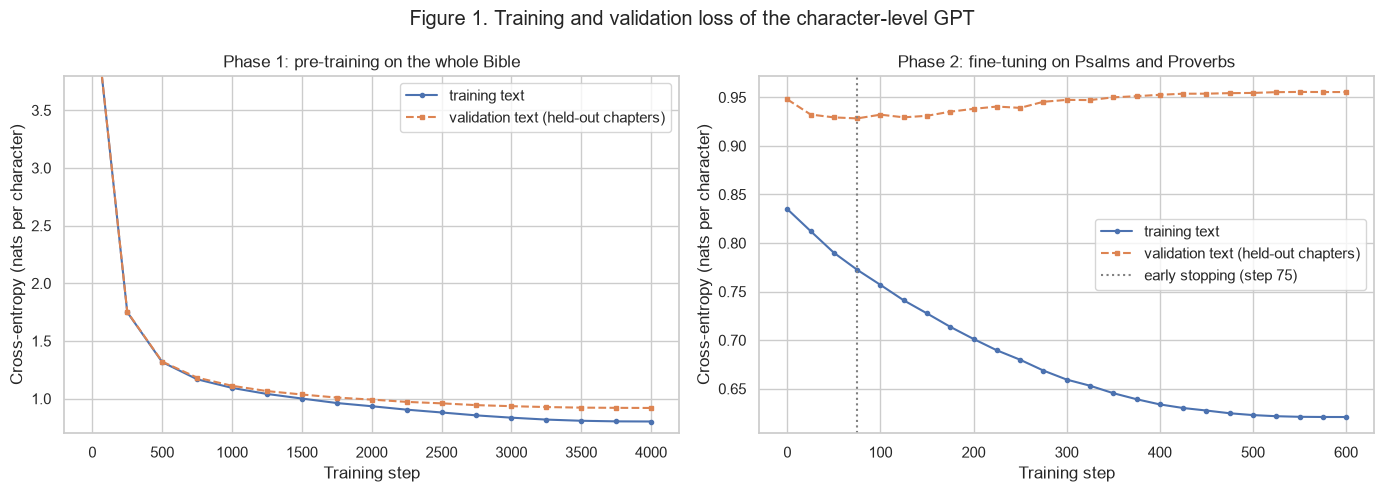

pre-training (whole Bible): final train loss 0.8020, final val loss 0.9194


,Psalms/Proverbs train loss,Psalms/Proverbs val loss,val perplexity per character,train - val gap
pre-trained only,0.8349,0.9479,2.5803,-0.1130
"fine-tuned, early-stopped",0.7725,0.9283,2.5303,-0.1558
"fine-tuned, overfitted (step 600)",0.6209,0.9555,2.5999,-0.3346


In [12]:
# Figure 1 — training diagnostics of both phases
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, hist, title in [(axes[0], hist_pre, "Phase 1: pre-training on the whole Bible"),
                        (axes[1], hist_ft, "Phase 2: fine-tuning on Psalms and Proverbs")]:
    ax.plot(hist.step, hist.train_loss, "-o", ms=3, label="training text")
    ax.plot(hist.step, hist.val_loss, "--s", ms=3, label="validation text (held-out chapters)")
    ax.set_title(title)
    ax.set_xlabel("Training step")
    ax.set_ylabel("Cross-entropy (nats per character)")
axes[1].axvline(best_step, color="gray", ls=":", label=f"early stopping (step {best_step})")
for ax in axes:
    ax.legend()
axes[0].set_ylim(0.7, 3.8)
fig.suptitle("Figure 1. Training and validation loss of the character-level GPT")
fig.tight_layout()
fig.savefig(FIG_DIR / "fig1_training_loss.png", dpi=150, bbox_inches="tight")
plt.show()

# Loss on the Psalms/Proverbs text for the three models compared below
comparison = {}
for name, state in [("pre-trained only", pretrained_state), ("fine-tuned, early-stopped", finetuned_state), ("fine-tuned, overfitted (step 600)", overfit_state)]:
    model.load_state_dict(state)
    comparison[name] = estimate_loss(model, data["finetune_train"], data["finetune_val"])
final = pd.DataFrame(comparison).T.rename(columns={"train": "Psalms/Proverbs train loss", "val": "Psalms/Proverbs val loss"})
final["val perplexity per character"] = np.exp(final["Psalms/Proverbs val loss"])
final["train - val gap"] = final["Psalms/Proverbs train loss"] - final["Psalms/Proverbs val loss"]
print(f"pre-training (whole Bible): final train loss {hist_pre.train_loss.iloc[-1]:.4f}, final val loss {hist_pre.val_loss.iloc[-1]:.4f}")
final.round(4)

## 5. Generation

Text is generated one character at a time: the model gives a probability distribution over the next character, one character is sampled, appended and fed back, until a newline ends the verse. The **temperature** divides the logits before the softmax: low temperatures make the model pick the most likely characters (safe but repetitive text), high temperatures flatten the distribution (more varied but less coherent text). A fixed random seed per sample makes every output reproducible.

In [13]:
@torch.no_grad()
def generate(model: nn.Module, prompt: str, temperature: float = 0.8, max_new_chars: int = 300, seed: int = 0) -> str:
    """Sample a continuation of ``prompt`` until a newline (end of verse) or ``max_new_chars`` characters."""
    model.eval()
    g = torch.Generator(device=DEVICE).manual_seed(seed)
    idx = encode(prompt).unsqueeze(0).to(DEVICE)
    for _ in range(max_new_chars):
        logits = model(idx[:, -BLOCK_SIZE:])[:, -1, :] / temperature
        next_id = torch.multinomial(F.softmax(logits, dim=-1), num_samples=1, generator=g)
        idx = torch.cat([idx, next_id], dim=1)
        if ITOS[next_id.item()] == "\n":
            break
    return decode(idx[0].tolist()).rstrip("\n")


def load(state: dict) -> nn.Module:
    model.load_state_dict(state)
    return model

In [14]:
# Multiple samples: the same prompts and seeds for the three models (temperature 0.8)
rows = []
for stage_name, state in [("pre-trained only", pretrained_state), ("fine-tuned, early-stopped", finetuned_state), ("fine-tuned, overfitted", overfit_state)]:
    m = load(state)
    for prompt in ["PSA: ", "PRO: "]:
        for seed in range(3):
            rows.append({"model": stage_name, "prompt": prompt.strip(), "seed": seed, "generated verse": generate(m, prompt, 0.8, seed=seed)[5:]})
samples_by_stage = pd.DataFrame(rows)
samples_by_stage

,model,prompt,seed,generated verse
0,pre-trained only,PSA:,0,"Y acontecerá que como los siervos de Adullam invocan á ellos, dice Jehová."
1,pre-trained only,PSA:,1,"Porque yo he alegido mi escudo por causa de mi alma, y la casa de Jehová me hará esconder en el día de mi angustia."
2,pre-trained only,PSA:,2,Porque Jehová es vuestro Dios de los ejércitos; por eso los enseñaré yo de mi gloria.
3,pre-trained only,PRO:,0,"Oh Jehová, á los que están en mí, estádome á la medida en que me declarare."
4,pre-trained only,PRO:,1,"Porque ciertamente humillasteis á los primeros de los santos, y el profeta conoce á los siervos de los sabios."
5,pre-trained only,PRO:,2,Porque Jehová es vuestro Dios de los cielos es Dios en la tierra; porque es menester que el padre testigo de vuestros padres es amigo.
6,"fine-tuned, early-stopped",PSA:,0,"Y acabaron á Jehová, y siguieron contra ella inclinados: y su gloria no se acordaron de la tierra los que mataron."
7,"fine-tuned, early-stopped",PSA:,1,"Porque yo he alegrado en tu socorro; júbilo en tu generación, y en tu buena guarda mi alma."
8,"fine-tuned, early-stopped",PSA:,2,"Porque Jehová es al malo en mi afrenta, y para sus saludes."
9,"fine-tuned, early-stopped",PRO:,0,"Oye, hijo mío, amigo mío; y ve mi corazón, á invocante en ti, oh Jehová, lo afligido y muerte."


In [15]:
# Multiple samples from the early-stopped fine-tuned model at four temperatures, with and without a starting phrase
m = load(finetuned_state)
rows = []
for temperature in [0.5, 0.8, 1.0, 1.3]:
    for prompt in ["PSA: ", "PRO: ", "PSA: Bienaventurado", "PRO: El hijo sabio"]:
        rows.append({"temperature": temperature, "prompt": prompt, "generated verse": generate(m, prompt, temperature, seed=7)[5:]})
samples_by_temperature = pd.DataFrame(rows)
samples_by_temperature

,temperature,prompt,generated verse
0,0.5,PSA:,Y en Israel respondió: No hay Dios en toda la tierra.
1,0.5,PRO:,El perverso es el corazón de los impíos; y el que aborrece mi alma el justo.
2,0.5,PSA: Bienaventurado,"Bienaventurados los que están en la tierra, y andan en la tierra de su diestra."
3,0.5,PRO: El hijo sabio,El hijo sabio del hombre sabio es el hombre sabio; y el amigo del hombre será talado.
4,0.8,PSA:,Hizo paz en tierra con viejos; salterio en tu tierra y endemoniados.
5,0.8,PRO:,"Cuando el que tiene semejante al hombre ó al muerto, es muerto en el cuerpo de la soledad."
6,0.8,PSA: Bienaventurado,"Bienaventurados ellos, que les acordó de ti mis palabras; misericordioso mío, y mi clemente en ti."
7,0.8,PRO: El hijo sabio,El hijo sabio del hombre resplandece lejos; y señala es al hermano fiel malo.
8,1.0,PSA:,"HIJO mío, es la casa de Dios, que me ha engañado con mi alma:"
9,1.0,PRO:,"No á los que les acordan la ciencia, ni á la muerte, ni á los impíos cuentan en el mundo:"


## 6. Evaluating the Generated Text

Generated text has no single correct answer, so it is evaluated from several angles. Besides reading the samples, 150 verses are generated at each temperature (75 per prompt) and compared with the training corpus:

- **Invented-word rate:** share of generated words that never occur in the whole Bible (spelling errors or made-up words).
- **Memorization rate:** share of generated 6-word sequences that appear verbatim in the training text, and the longest copied span per verse. High values mean the model is reciting scripture instead of generating.
- **Repetition (distinct-2):** unique word pairs divided by all word pairs in the generated verses; low values mean loops such as *y los hijos de Israel, y los hijos de Israel*.
- **Style fidelity:** median verse length compared with the real Psalms and Proverbs.

In [16]:
WORD_RE = re.compile(r"[a-záéíóúüñ]+")
bible_words = set(WORD_RE.findall(" ".join(verses["clean"]).lower()))
train_words = WORD_RE.findall(texts["pretrain_train"].lower())
train_6grams = {tuple(train_words[i:i + 6]) for i in range(len(train_words) - 5)}


def longest_copied_span(words: list[str]) -> int:
    """Length (in words) of the longest run of consecutive 6-grams found verbatim in the training text."""
    best = run = 0
    for i in range(len(words) - 5):
        run = run + 1 if tuple(words[i:i + 6]) in train_6grams else 0
        best = max(best, run + 5 if run else 0)
    return best


def evaluate_samples(samples: list[str]) -> dict:
    """Invented-word rate, 6-gram memorization rate, longest copied span, distinct-2 and median length."""
    words = [WORD_RE.findall(s.lower()) for s in samples]
    flat = [w for ws in words for w in ws]
    grams6 = [tuple(ws[i:i + 6]) for ws in words for i in range(len(ws) - 5)]
    bigrams = [tuple(ws[i:i + 2]) for ws in words for i in range(len(ws) - 1)]
    return {
        "invented-word rate": sum(w not in bible_words for w in flat) / max(len(flat), 1),
        "memorized 6-gram rate": sum(g in train_6grams for g in grams6) / max(len(grams6), 1),
        "median longest copied span (words)": float(np.median([longest_copied_span(ws) for ws in words])),
        "distinct-2": len(set(bigrams)) / max(len(bigrams), 1),
        "median length (characters)": float(np.median([len(s) for s in samples])),
    }


N_PER_PROMPT = 75
metrics, generated = [], {}
m = load(finetuned_state)
for temperature in [0.5, 0.8, 1.0, 1.3]:
    samples = [generate(m, p, temperature, seed=1000 + i)[5:] for p in ("PSA: ", "PRO: ") for i in range(N_PER_PROMPT)]
    generated[temperature] = samples
    metrics.append({"temperature": temperature, **evaluate_samples(samples)})
real = verses[verses.book.isin(["PSA", "PRO"]) & (verses.split == "val")]["clean"].tolist()
reference = evaluate_samples(real)
metrics_table = pd.DataFrame(metrics + [{"temperature": "real verses (held-out)", **reference}]).set_index("temperature").round(3)
metrics_table

,invented-word rate,memorized 6-gram rate,median longest copied span (words),distinct-2,median length (characters)
temperature,,,,,
0.5,0.004,0.041,0.0,0.526,80.0
0.8,0.019,0.006,0.0,0.720,76.0
1.0,0.047,0.008,0.0,0.805,73.0
1.3,0.110,0.001,0.0,0.889,71.0
real verses (held-out),0.000,0.022,0.0,0.728,79.0


In [17]:
# The same diagnostics for the three models at temperature 0.8
model_rows = []
for name, state in [("pre-trained only", pretrained_state), ("fine-tuned, early-stopped", finetuned_state), ("fine-tuned, overfitted", overfit_state)]:
    m = load(state)
    samples = generated[0.8] if name == "fine-tuned, early-stopped" else [generate(m, p, 0.8, seed=1000 + i)[5:] for p in ("PSA: ", "PRO: ") for i in range(N_PER_PROMPT)]
    generated[name] = samples
    model_rows.append({"model (T = 0.8)": name, **evaluate_samples(samples)})
model_rows.append({"model (T = 0.8)": "real verses (held-out)", **reference})
model_table = pd.DataFrame(model_rows).set_index("model (T = 0.8)").round(3)
m = load(finetuned_state)
model_table

,invented-word rate,memorized 6-gram rate,median longest copied span (words),distinct-2,median length (characters)
model (T = 0.8),,,,,
pre-trained only,0.016,0.007,0.0,0.702,95.0
"fine-tuned, early-stopped",0.019,0.006,0.0,0.720,76.0
"fine-tuned, overfitted",0.016,0.014,0.0,0.685,85.0
real verses (held-out),0.000,0.022,0.0,0.728,79.0


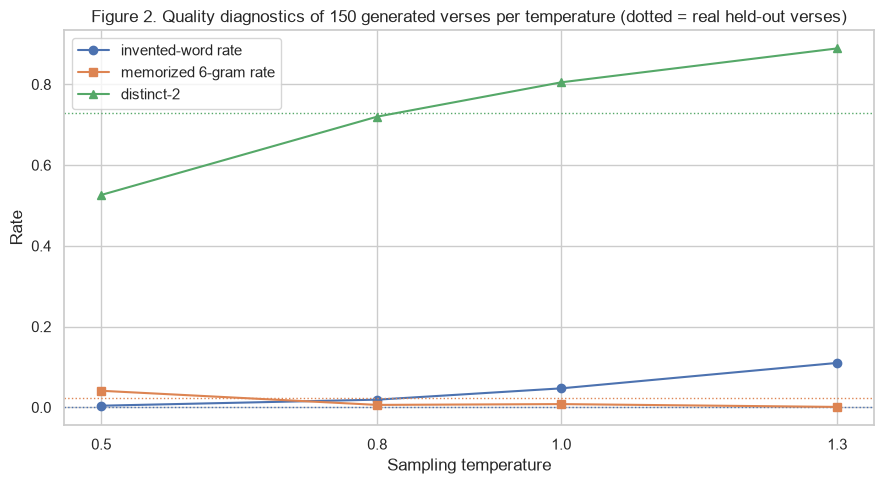

In [18]:
# Figure 2 — how the sampling temperature trades memorization and repetition against invented words
plot_df = metrics_table.drop(index="real verses (held-out)").reset_index()
fig, ax = plt.subplots(figsize=(9, 5))
for col, marker in [("invented-word rate", "o"), ("memorized 6-gram rate", "s"), ("distinct-2", "^")]:
    ax.plot(plot_df["temperature"], plot_df[col], marker=marker, label=col)
    ax.axhline(metrics_table.loc["real verses (held-out)", col], ls=":", color=ax.lines[-1].get_color(), lw=1)
ax.set_title("Figure 2. Quality diagnostics of 150 generated verses per temperature (dotted = real held-out verses)")
ax.set_xlabel("Sampling temperature")
ax.set_ylabel("Rate")
ax.set_xticks(plot_df["temperature"])
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "fig2_temperature_diagnostics.png", dpi=150, bbox_inches="tight")
plt.show()

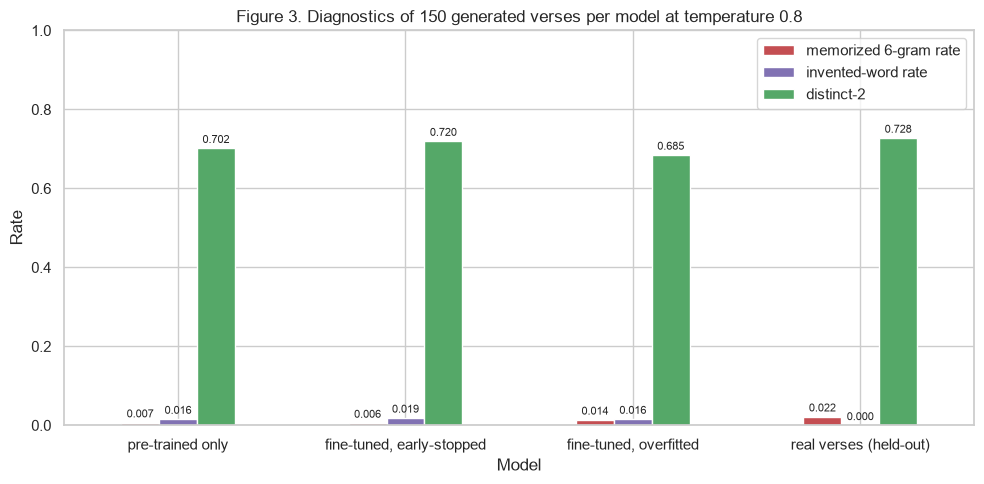

In [19]:
# Figure 3 — memorization and invented words for the three models at temperature 0.8
bars = model_table[["memorized 6-gram rate", "invented-word rate", "distinct-2"]]
fig, ax = plt.subplots(figsize=(10, 5))
bars.plot(kind="bar", ax=ax, color=["#C44E52", "#8172B3", "#55A868"], rot=0)
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", fontsize=8, padding=2)
ax.set_title("Figure 3. Diagnostics of 150 generated verses per model at temperature 0.8")
ax.set_xlabel("Model")
ax.set_ylabel("Rate")
ax.set_ylim(0, 1)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig3_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

In [20]:
# Concrete failure cases found automatically in the samples at temperature 0.8 and 1.3
def invented(s: str) -> list[str]:
    return [w for w in WORD_RE.findall(s.lower()) if w not in bible_words]

cases = {
    "longest verbatim copy (T=0.5)": max(generated[0.5], key=lambda s: longest_copied_span(WORD_RE.findall(s.lower()))),
    "longest verbatim copy, overfitted model (T=0.8)": max(generated["fine-tuned, overfitted"], key=lambda s: longest_copied_span(WORD_RE.findall(s.lower()))),
    "most invented words (T=1.3)": max(generated[1.3], key=lambda s: len(invented(s))),
    "a verse with invented words (T=0.8)": next(s for s in generated[0.8] if invented(s)),
}
for name, s in cases.items():
    print(f"{name}:\n  {s}\n  invented words: {invented(s)} | longest copied span: {longest_copied_span(WORD_RE.findall(s.lower()))} words\n")

longest verbatim copy (T=0.5):
  El león es el que para siempre en medio de los hijos de los hombres, y el que habla maldad de contiendas.
  invented words: [] | longest copied span: 10 words

longest verbatim copy, overfitted model (T=0.8):
  Bendito Jehová, que para siempre es su misericordia, y que para siempre es su misericordia.
  invented words: [] | longest copied span: 8 words

most invented words (T=1.3):
  El encruelto es cortado y bálsagro, en que aborrece la maldad. OL-ARSE NO á impiedad; aflicción es de refugio según la palabra del hombre impío: el hombre vivirá olvidador. ¿EL entendido clamasteis son vanidades?) Jehová es juzgadoría.
  invented words: ['encruelto', 'bálsagro', 'ol', 'arse', 'olvidador', 'clamasteis', 'juzgadoría'] | longest copied span: 0 words

a verse with invented words (T=0.8):
  No obstingues en nuestras manos, ni aparen las vanidades de las nubes;
  invented words: ['obstingues', 'aparen'] | longest copied span: 0 words



### Qualitative evaluation

- **Fine-tuning changes the style, not only the loss.** With the same prompts and seeds, the pre-trained-only model writes narrative or prophetic lines that could come from any book (*Y acontecerá que como los siervos de Adullam invocan á ellos, dice Jehová*, with the prophetic formula *dice Jehová*). After fine-tuning, the lines take the first-person, prayer-like voice of the Psalms (*Porque yo he alegrado en tu socorro; júbilo en tu generación, y en tu buena guarda mi alma*) and the address formula of Proverbs (*Oye, hijo mío, amigo mío*). The median length of the generated verses also moves from 95 characters (pre-trained only) to 76 (fine-tuned), close to the 79 characters of real Psalms and Proverbs.
- **Strengths.** The model reproduces the 1909 orthography and grammar that it was never told about: the accented preposition *á*, enclitic pronouns (*acordóse*, *guiaráme*-style forms), the colon and semicolon structure of Hebrew parallelism, and the antithetic parallelism of Proverbs introduced by *mas* (*mas el que se encubre la palabra, será cortado*). At temperature 0.8 almost every word is a real word of the Bible (invented-word rate 0.019) and the diversity of word pairs (distinct-2 of 0.720) is close to that of real verses (0.728).
- **The model does not recite scripture at normal temperatures.** Only 0.6 % of the generated 6-word sequences at temperature 0.8 appear verbatim in the training text, fewer than the 2.2 % that real held-out verses share with the training text through formulaic phrases. Copying rises when sampling becomes greedy: at temperature 0.5 the rate is 4.1 % and the longest copied span reaches 10 words.
- **Failure case 1 — coherence.** Most lines are grammatical but meaningless when read as a whole: *Porque Jehová es al malo en mi afrenta, y para sus saludes*. The model learns local patterns of 1909 Spanish, not meaning.
- **Failure case 2 — repetition at low temperature.** At temperature 0.5 the model falls into loops (*El hijo sabio del hombre sabio es el hombre sabio*), and the distinct-2 score drops to 0.526. The overfitted model also repeats a refrain within one line (*Bendito Jehová, que para siempre es su misericordia, y que para siempre es su misericordia*), echoing Psalm 136, whose every verse ends with *porque para siempre es su misericordia*.
- **Failure case 3 — invented words at high temperature.** At temperature 1.3, 11 % of the words do not exist in the Bible (*encruelto*, *bálsagro*, *juzgadoría*) and formatting breaks (*HIJJehová*, *OL-ARSE NO*).
- **Failure case 4 — theologically wrong statements in a scriptural voice.** At temperature 0.5 the model produced *Y en Israel respondió: No hay Dios en toda la tierra.* The sentence imitates the register of scripture perfectly while stating the opposite of the text it was trained on, which is the central ethical risk of this system.
- **Choice of temperature.** Figure 2 shows the trade-off: low temperatures copy more and repeat more, high temperatures invent words. Temperature 0.8 gives the best balance, with diversity matching real verses, less copying than real verses and about 2 % invented words.

## 7. Summary

I trained a 10.8-million-parameter character-level GPT from scratch to generate Spanish verses in the style of the Psalms and Proverbs of the public-domain 1909 Reina-Valera Bible, pre-training it on the whole Bible and then fine-tuning it on the two target books with early stopping. The generated lines reproduce the 1909 spelling, the parallel structure and the typical formulas of the two books, and fine-tuning moves their style and length (median 76 characters, against 79 for real verses) away from the narrative voice of the pre-trained model. The main training challenge was overfitting during fine-tuning: the Psalms and Proverbs text is small, the validation loss reached its minimum after only 75 steps (0.9283) and then rose, so early stopping was needed to keep the best weights. The model does not recite scripture at temperature 0.8 (0.6 % of its 6-word sequences are copied, fewer than the 2.2 % that real verses share with the training text), but its lines are often meaningless, it loops at low temperatures and invents words at high ones. Its most serious failure is ethical rather than technical: it can produce statements that contradict the Bible, such as *No hay Dios en toda la tierra*, in a voice that sounds exactly like scripture.